# LAPTOP PRICES PROJECT

🎯 **Business Understanding & Objective**

Global market dynamics in the consumer electronics sector reveal that laptop pricing is governed by complex hardware configurations rather than isolated component costs. The objective of this study is to perform a comprehensive Exploratory Data Analysis (EDA) on a comprehensive laptop dataset to decipher pricing mechanics, evaluate market segmentation, and identify key value drivers across hardware specifications (e.g., CPU/GPU synergies, RAM capacity, display technologies, and form factors).


📊 **Dataset Attributes**
The dataset contains 12 attributes detailing physical, technical, and commercial specifications of laptops:

**Company:** Laptop manufacturer / brand  
**Product:** Commercial brand model name  
**TypeName:** Market category / form factor ("Notebook", "Gaming", "Ultrabook", "Workstation", "2 in 1 Convertible", or "Netbook")  
**Inches:** Screen diagonal size in inches  
**ScreenResolution:** Display resolution and panel technology features (e.g., Full HD, 4K Ultra HD, Touchscreen)  
**Cpu:** Central Processing Unit model and clock speed (GHz)  
**Ram:** System memory capacity in gigabytes (GB)  
**Memory:** Storage unit capacity and technology type (e.g., SSD, HDD, Flash Storage, Hybrid)  
**Gpu:** Graphics Processing Unit model and manufacturer  
**OpSys:** Pre-installed operating system  
**Weight:** Device physical weight in kilograms (kg)  
**Price:** Unit retail sales price (Target Variable)  

🛠️ **Project Roadmap**

**Environment & Data Preprocessing:** Importing core Python libraries, reading data, and verifying data types and structural integrity.  

**Univariate & Bivariate EDA:** Analyzing individual feature distributions and direct relationships between hardware attributes (CPU, GPU, RAM, Storage) and price.  

**Categorical Market Segmentation:** Evaluating market share versus mean pricing across distinct TypeName categories.  

**Feature Impact Analysis:** Assessing display feature impacts (specifically Touchscreen and resolution tiers) on baseline price and outlier distributions via IQR analysis.  

**High-End Archetype Case Study:** Deep-diving into the highest-priced model (Razer Gaming Laptop) to validate the "Holistic Hardware Bundle" hypothesis.  

**Executive Synthesis & Conclusion:** Consolidating statistical insights and domain logic into a professional summary report.  

## <span style=" color:red"> Import Libraries, Loading the Dataset and Initial Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno
import plotly.express as px
import folium
from folium import plugins

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

In [3]:
df0 = pd.read_csv("laptop_data.csv")
df = df0.copy()

In [4]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
df.shape

(1303, 12)

In [6]:
df.info()

# We observe that our dataset consists of 1,303 rows and 12 columns,
# with data types distributed as 9 object, 2 float, and 1 int,
# and containing no missing (null) values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [7]:
# Checking for missing values

df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [8]:
pd.DataFrame({
    'Count': df.count(),
    'Null': df.isnull().sum(),
    'Cardinality': df.nunique()
})

,Count,Null,Cardinality
Unnamed: 0,1303,0,1303
Company,1303,0,19
TypeName,1303,0,6
Inches,1303,0,18
ScreenResolution,1303,0,40
Cpu,1303,0,118
Ram,1303,0,9
Memory,1303,0,39
Gpu,1303,0,110
OpSys,1303,0,9


In [123]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inches,1274.0,15.022449,1.429940,10.10,14.0000,15.60,15.60,18.40
Ram,1274.0,8.444270,5.098291,2.00,4.0000,8.00,8.00,64.00
Weight,1274.0,2.040400,0.669444,0.69,1.5000,2.04,2.31,4.70
Price,1274.0,60503.185074,37333.222977,9270.72,32495.6052,52693.92,79773.48,324954.72


1. **Column Filtering & Feature Selection**

The `Unnamed: 0` column is dropped from further analysis as it merely functions as a redundant index feature.

3. **Key Summary Statistics & Feature Insights**

**Inches (Screen Size):**
The distribution spans from a minimum of 10.10 to a maximum of 18.40 inches.
With a mean of 15.01 and a median of 15.60, the close alignment between central tendency metrics and uniform quartile spacing 
suggests a near-normal distribution with minimal outlier risk. However, distributional plots and boxplots are required to confirm normality.

**Price (Target Variable):**
Retail prices range significantly from a minimum of 9,270 to a maximum of 324,954.
The notable rightward divergence between the mean (59,870) and median (52,054), alongside a sharp spike between the 75th percentile and maximum value, strongly indicates a right-skewed distribution driven by high-end outliers. A detailed distribution and IQR outlier analysis will follow to validate this structure.

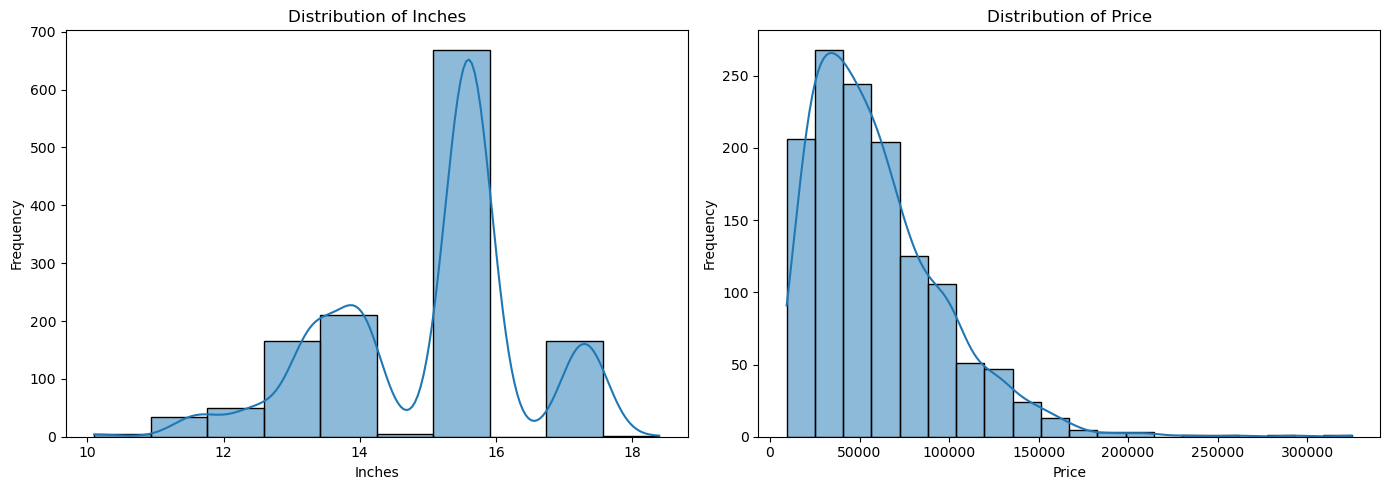

In [10]:
# Check feature distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inches dist.

sns.histplot(data=df, x="Inches", bins=10, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Inches")
axes[0].set_xlabel("Inches")
axes[0].set_ylabel("Frequency")

# Price dist.

sns.histplot(data=df, x="Price", bins=20, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Price")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Inches (Screen Size) Distribution:**
The multimodal pattern indicates distinct clustering around standard screen form factors.
A dominant peak is centered at 15.6 inches, followed by notable concentrations around 14 and 13.3 inches.
Extremely small and large display sizes represent a minor share of the dataset.

**Price (Target Variable) Distribution:**
The density plot exhibits a clear right-skewed distribution.
Observations heavily cluster around the 40,000–50,000 price band, with frequency dropping significantly as price increases.
This confirms that high-end, premium laptops constitute a low-volume minority in the market.

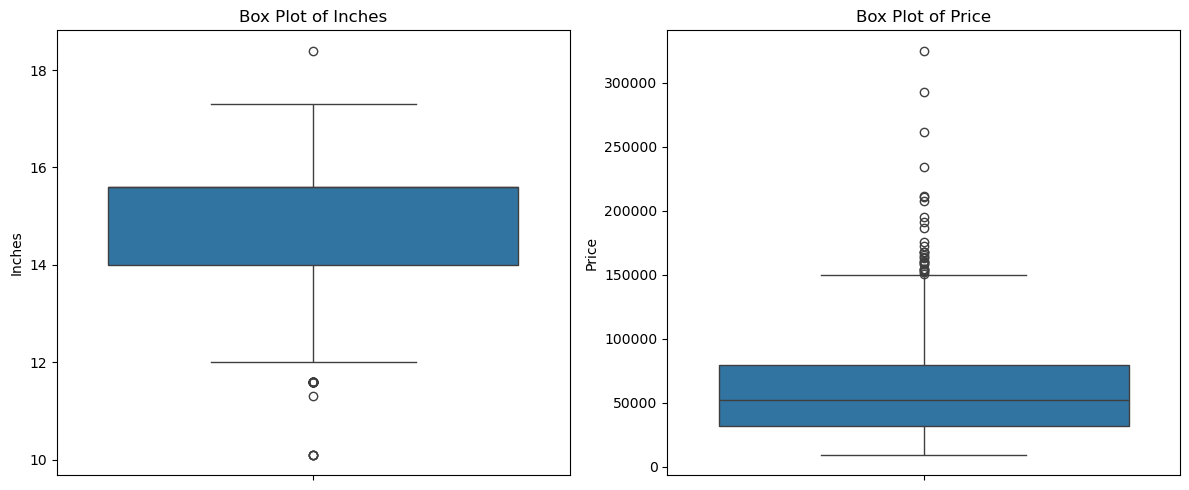

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Inches
sns.boxplot(y=df["Inches"], ax=axes[0])
axes[0].set_title("Box Plot of Inches")
axes[0].set_ylabel("Inches")

# Price
sns.boxplot(y=df["Price"], ax=axes[1])
axes[1].set_title("Box Plot of Price")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

**Inches (Screen Size) Outlier Analysis:**
Based on the boxplot distribution, display sizes of 12 inches and below, as well as values above 18 inches, are identified as statistical outliers.

**Price (Target Variable) Outlier Analysis:**
The price distribution reveals that values exceeding 150,000 are categorized as upper-bound outliers, reflecting the premium segment of the dataset.

In [14]:
df["Inches"].unique()

# Evaluating identified outliers:
# Although these points are flagged as statistical outliers, domain context indicates they represent legitimate high-end market configurations 
# rather than data entry errors. Consequently, no rows will be removed.

array([13.3, 15.6, 15.4, 14. , 12. , 11.6, 17.3, 10.1, 13.5, 12.5, 13. ,
       18.4, 13.9, 12.3, 17. , 15. , 14.1, 11.3])

In [15]:
df.sort_values(by="Price", ascending=False).head(5)

# Price Outlier Assessment:
# While high price values are observed, the absence of a specified currency in the dataset prevents confirming these figures as errors.
# Lacking definitive evidence of data entry mistakes or domain anomalies, these outliers are retained to preserve high-end market signals.
# Should these extreme values distort subsequent analyses, isolating them for separate evaluation or temporary exclusion will be considered.

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
196,196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,324954.72
830,830,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32GB,512GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49kg,292986.72
610,610,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32GB,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.5kg,261018.72
749,749,HP,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Xeon E3-1535M v5 2.9GHz,16GB,256GB SSD,Nvidia Quadro M2000M,Windows 7,3kg,233845.92
1066,1066,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,64GB,1TB SSD,Nvidia GeForce GTX 980,Windows 10,3.58kg,211788.00


## <span style=" color:red"> Data Cleaning: 

### <span style=" color:red"> Remove unnecessary columns:
</span>


In [16]:
df.drop("Unnamed: 0", axis=1, inplace=True)

# Dropping the extra index column.

In [17]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

### <span style=" color:red"> Check for duplicates and missing values:

In [18]:
df.duplicated().sum()

#29 duplicated rows.

np.int64(29)

In [19]:
df = df.drop_duplicates(ignore_index = True) #drop duplicated.

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.isnull().sum().sum()

# no missing value

np.int64(0)

### <span style=" color:red"> Standardize data formats:

In [22]:
df.dtypes

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object

In [23]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


In [24]:
df["Ram"].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB'],
      dtype=object)

In [25]:
df["Ram"] = df["Ram"].str.replace("GB", "", regex=False).astype(int)

In [26]:
df["Ram"].unique() 

array([ 8, 16,  4,  2, 12,  6, 32, 24, 64])

In [27]:
df["Weight"].unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', '0.98kg', '2.5kg', '1.62kg',
       '1.91kg', '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg',
       '2.71kg', '1.2kg', '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg',
       '3.2kg', '0.69kg', '1.49kg', '2.4kg', '2.13kg', '2.43kg', '1.7kg',
       '1.4kg', '1.8kg', '1.9kg', '3kg', '1.252kg', '2.7kg', '2.02kg',
       '1.63kg', '1.96kg', '1.21kg', '2.45kg', '1.25kg', '1.5kg',
       '2.62kg', '1.38kg', '1.58kg', '1.85kg', '1.23kg', '1.26kg',
       '2.16kg', '2.36kg', '2.05kg', '1.32kg', '1.75kg', '0.97kg',
       '2.9kg', '2.56kg', '1.48kg', '1.74kg', '1.1kg', '1.56kg', '2.03kg',
       '1.05kg', '4.4kg', '1.90kg', '1.29kg', '2.0kg', '1.95kg', '2.06kg',
       '1.12kg', '1.42kg', '3.49kg', '3.35kg', '2.23kg', '4.42kg',
       '2.69kg', '2.37kg', '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg',
       '1.41kg', '4.14kg', '2.18kg', '2.24kg', '2.67kg', '2.14kg',
       '1.

In [28]:
df["Weight"] = df["Weight"].str.replace("kg", "", regex=False).astype(float) 

# Removing 'kg' suffix and converting Weight to numeric type.

In [29]:
df["Weight"].unique()

array([1.37 , 1.34 , 1.86 , 1.83 , 2.1  , 2.04 , 1.3  , 1.6  , 2.2  ,
       0.92 , 1.22 , 0.98 , 2.5  , 1.62 , 1.91 , 2.3  , 1.35 , 1.88 ,
       1.89 , 1.65 , 2.71 , 1.2  , 1.44 , 2.8  , 2.   , 2.65 , 2.77 ,
       3.2  , 0.69 , 1.49 , 2.4  , 2.13 , 2.43 , 1.7  , 1.4  , 1.8  ,
       1.9  , 3.   , 1.252, 2.7  , 2.02 , 1.63 , 1.96 , 1.21 , 2.45 ,
       1.25 , 1.5  , 2.62 , 1.38 , 1.58 , 1.85 , 1.23 , 1.26 , 2.16 ,
       2.36 , 2.05 , 1.32 , 1.75 , 0.97 , 2.9  , 2.56 , 1.48 , 1.74 ,
       1.1  , 1.56 , 2.03 , 1.05 , 4.4  , 1.29 , 1.95 , 2.06 , 1.12 ,
       1.42 , 3.49 , 3.35 , 2.23 , 4.42 , 2.69 , 2.37 , 4.7  , 3.6  ,
       2.08 , 4.3  , 1.68 , 1.41 , 4.14 , 2.18 , 2.24 , 2.67 , 2.14 ,
       1.36 , 2.25 , 2.15 , 2.19 , 2.54 , 3.42 , 1.28 , 2.33 , 1.45 ,
       2.79 , 1.84 , 2.6  , 2.26 , 3.25 , 1.59 , 1.13 , 1.78 , 1.15 ,
       1.27 , 1.43 , 2.31 , 1.16 , 1.64 , 2.17 , 1.47 , 3.78 , 1.79 ,
       0.91 , 1.99 , 4.33 , 1.93 , 1.87 , 2.63 , 3.4  , 3.14 , 1.94 ,
       1.24 , 4.6  ,

In [30]:
df.dtypes

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price               float64
dtype: object

### <span style=" color:red"> Clean categorical columns:

In [31]:
df["Company"].unique() # No issues detected.

array(['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'Chuwi', 'MSI',
       'Microsoft', 'Toshiba', 'Huawei', 'Xiaomi', 'Vero', 'Razer',
       'Mediacom', 'Samsung', 'Google', 'Fujitsu', 'LG'], dtype=object)

In [32]:
df["TypeName"].unique() # No issues detected.

array(['Ultrabook', 'Notebook', 'Netbook', 'Gaming', '2 in 1 Convertible',
       'Workstation'], dtype=object)

In [33]:
df["OpSys"].unique() 

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [34]:
# Standardizing redundant labels representing the exact same operating system.
# Other categories remain separate as they represent distinct OS versions.

df["OpSys"] = df["OpSys"].replace({
    "Mac OS X": "macOS"
})

In [35]:
df["OpSys"].unique() 

array(['macOS', 'No OS', 'Windows 10', 'Linux', 'Android', 'Windows 10 S',
       'Chrome OS', 'Windows 7'], dtype=object)

In [36]:
df["Company"] = df["Company"].str.strip()
df["TypeName"] = df["TypeName"].str.strip()
df["OpSys"] = df["OpSys"].str.strip()

# Cleaned whitespace from text fields.

### <span style=" color:red"> Split compound columns:

In [37]:
df["ScreenResolution"].unique() # ScreenResolution unique values.

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

In [38]:
df["Resolution"] = df["ScreenResolution"].str.rsplit(" ", n=1).str[-1]

# Extracted resolution values (e.g., '1440x900') from the end of the text strings and stored them in a new 'Resolution' column.

In [39]:
df["Touchscreen"] = df["ScreenResolution"].str.contains("Touchscreen", case=False)

# Created a new 'Touchscreen' boolean column, assigning 'True' if the display feature is present and 'False' otherwise. 

In [40]:
df["IPS"] = df["ScreenResolution"].str.contains("IPS Panel", case=False)

# Created a new 'IPS' boolean column, assigning 'True' if IPS panel technology is present and 'False' otherwise.

In [124]:
def ekran_tipi_ayikla_split_gelismis(metin):
    ekran_tipleri_listesi = ["4K Ultra HD", "Full HD", "Quad HD+", "Retina Display"]
    metin_lower = metin.lower()
    for tip in ekran_tipleri_listesi:
         if tip.lower() in metin_lower: 
             return tip.upper() 
    return 'OTHER'
df['Screen_Type'] = df['ScreenResolution'].apply(ekran_tipi_ayikla_split_gelismis)

# Defined a custom parsing function to isolate display panel categories and assigned the extracted panel types to a new 'Screen_Type' feature.

In [42]:
df.head(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,Touchscreen,IPS,Screen_Type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560x1600,False,True,RETINA DISPLAY
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440x900,False,False,OTHER
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920x1080,False,False,FULL HD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880x1800,False,True,RETINA DISPLAY
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560x1600,False,True,RETINA DISPLAY


In [43]:
df['Cpu_Manufacturer'] = df['Cpu'].str.rsplit(' ').str[0] 

# Engineered a new feature by isolating processor manufacturer brand names into a standalone CPU brand column.

In [44]:
df['Gpu_Manufacturer'] = df['Gpu'].str.rsplit(' ').str[0]

# Engineered a new feature by isolating graphics card manufacturer brand names into a standalone GPU brand columm.

In [45]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,Touchscreen,IPS,Screen_Type,Cpu_Manufacturer,Gpu_Manufacturer
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560x1600,False,True,RETINA DISPLAY,Intel,Intel
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440x900,False,False,OTHER,Intel,Intel


### <span style=" color:red"> Check for outliers in numerical columns:

In [46]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inches,1274.0,15.022449,1.429940,10.10,14.0000,15.60,15.60,18.40
Ram,1274.0,8.444270,5.098291,2.00,4.0000,8.00,8.00,64.00
Weight,1274.0,2.040400,0.669444,0.69,1.5000,2.04,2.31,4.70
Price,1274.0,60503.185074,37333.222977,9270.72,32495.6052,52693.92,79773.48,324954.72


**Method Selection Policy (IQR vs. Z-Score):**

Rather than arbitrarily selecting an outlier detection technique, the choice must align with the underlying feature distribution.
Z-Score assumes a roughly normal distribution, whereas IQR is non-parametric and robust against non-normal or skewed data.

Strategy:
We will evaluate both methods side-by-side and commit to the final technique based on the empirical distribution of the target variable.

### 1. Inches

In [48]:
from scipy import stats
import numpy as np

In [49]:
# IQR

Q1 = df["Inches"].quantile(0.25)
Q3 = df["Inches"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Inches"] < lower_bound) | (df["Inches"] > upper_bound)]

print(f"IQR ile bulunan aykırı değer sayısı: {len(iqr_outliers)}")


# Z-score

z_scores = np.abs(stats.zscore(df["Inches"]))

zscore_outliers = df[z_scores > 3]

print(f"Z-score ile bulunan aykırı değer sayısı: {len(zscore_outliers)}")

IQR ile bulunan aykırı değer sayısı: 37
Z-score ile bulunan aykırı değer sayısı: 4


In [50]:
# Iqr ve Z-score farklı sayıda outlier değerleri buldu, bu değerler nelermiş bakalım:

In [51]:
print(iqr_outliers["Inches"].unique())

[11.6 10.1 18.4 11.3]


In [52]:
print(zscore_outliers["Inches"].unique())

[10.1]


In [125]:
# Due to the discrepancy in outlier counts between IQR and Z-Score, 
# we will examine the target distribution to select the appropriate detection method.

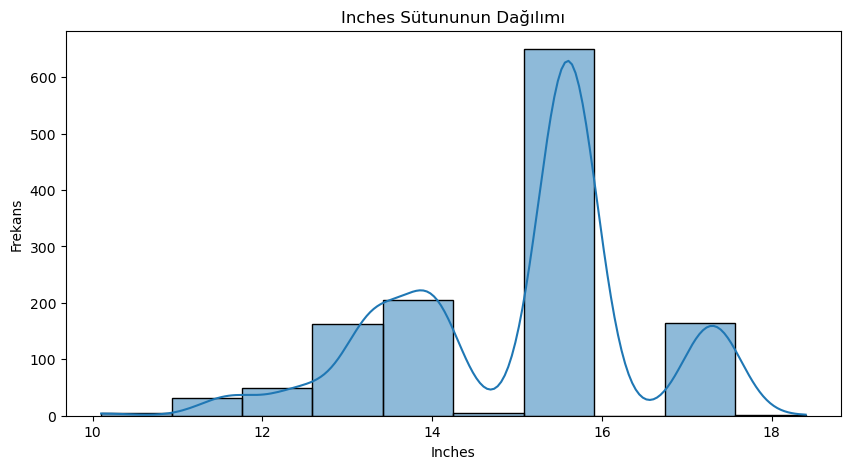

In [54]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Inches",
    bins=10,
    kde=True
)

plt.title("Inches Sütununun Dağılımı")
plt.xlabel("Inches")
plt.ylabel("Frekans")
plt.show()

In [55]:
# The 'Inches' feature exhibits a slight left-skewed distribution.
# Consequently, we apply the IQR method for outlier detection, 
# as it is non-parametric and more robust for skewed continuous features.

#### 2. Ram

In [56]:
# IQR

Q1 = df["Ram"].quantile(0.25)
Q3 = df["Ram"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Ram"] < lower_bound) | (df["Ram"] > upper_bound)]

print(f"IQR ile bulunan aykırı değer sayısı: {len(iqr_outliers)}")


# Z-score

z_scores = np.abs(stats.zscore(df["Ram"]))

zscore_outliers = df[z_scores > 3]

print(f"Z-score ile bulunan aykırı değer sayısı: {len(zscore_outliers)}")

IQR ile bulunan aykırı değer sayısı: 219
Z-score ile bulunan aykırı değer sayısı: 21


In [57]:
# Due to the discrepancy in outlier counts between IQR and Z-Score, 
# we will examine the target distribution to select the appropriate detection method.

In [58]:
print(iqr_outliers["Ram"].unique())

[16 32 24 64]


In [59]:
print(zscore_outliers["Ram"].unique())

[32 24 64]


In [60]:
# The IQR method identified 16-inch laptops as outliers. 
# Let's examine the target distribution to select the most appropriate detection strategy.

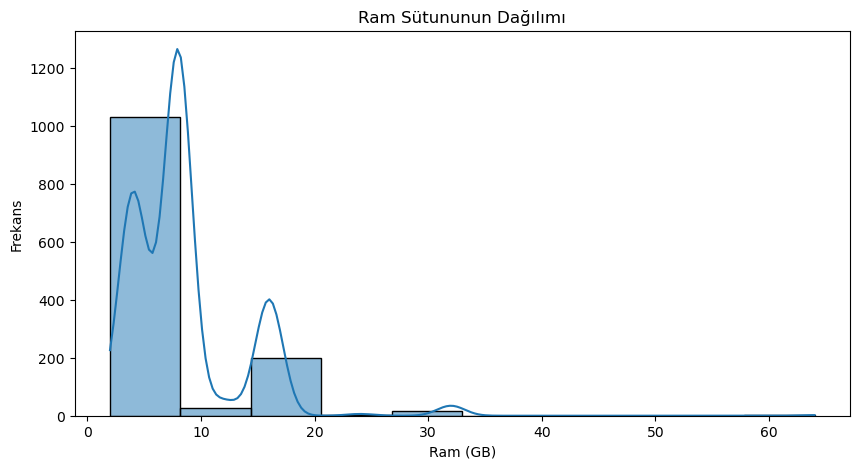

In [61]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Ram",
    bins=10,
    kde=True
)

plt.title("Ram Sütununun Dağılımı")
plt.xlabel("Ram (GB)")
plt.ylabel("Frekans")
plt.show()

In [62]:
# The feature exhibits a right-skewed distribution. 
# Consequently, the non-parametric IQR method is the appropriate strategy for identifying potential outliers.

### 3. Weight

In [63]:
# IQR

Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Weight"] < lower_bound) | (df["Weight"] > upper_bound)]

print(f"IQR ile bulunan aykırı değer sayısı: {len(iqr_outliers)}")


# Z-score

z_scores = np.abs(stats.zscore(df["Weight"]))

zscore_outliers = df[z_scores > 3]

print(f"Z-score ile bulunan aykırı değer sayısı: {len(zscore_outliers)}")

IQR ile bulunan aykırı değer sayısı: 45
Z-score ile bulunan aykırı değer sayısı: 33


In [64]:
# Due to the discrepancy in outlier counts between IQR and Z-Score, 
# we will examine the target distribution to select the appropriate detection method.

In [65]:
print(iqr_outliers["Weight"].unique())

[4.4  4.42 4.7  3.6  4.3  4.14 3.78 4.33 4.6  4.5  3.8  4.36 4.2  3.74
 3.58 4.  ]


In [66]:
print(zscore_outliers["Weight"].unique())

[4.4  4.42 4.7  4.3  4.14 4.33 4.6  4.5  4.36 4.2 ]


In [67]:
# Here, we also observed divergent outlier results: the IQR method identified a broader range of outlier candidates.
# To select the most appropriate methodology, we will examine the underlying feature distribution.

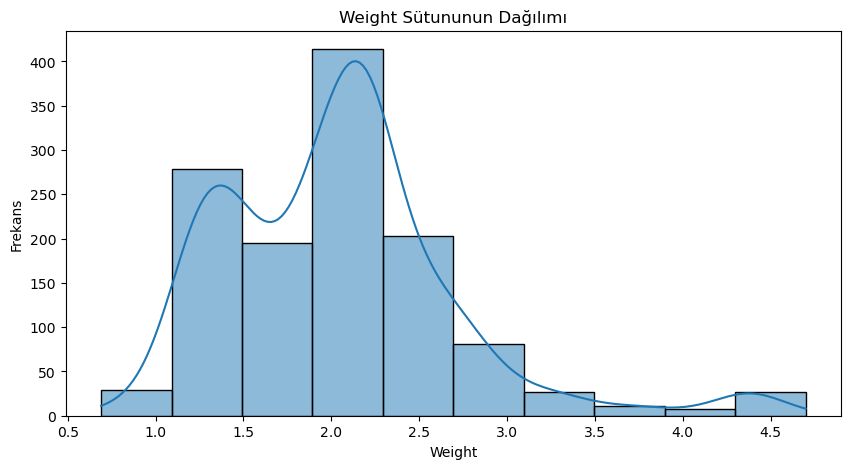

In [68]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Weight",
    bins=10,
    kde=True
)

plt.title("Weight Sütununun Dağılımı")
plt.xlabel("Weight")
plt.ylabel("Frekans")
plt.show()

In [69]:
# The distribution is clearly right-skewed. Consequently, applying the IQR method is the more appropriate strategy.

### 4. Price

In [70]:
# IQR

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Price"] < lower_bound) | (df["Price"] > upper_bound)]

print(f"IQR ile bulunan aykırı değer sayısı: {len(iqr_outliers)}")


# Z-score

z_scores = np.abs(stats.zscore(df["Price"]))

zscore_outliers = df[z_scores > 3]

print(f"Z-score ile bulunan aykırı değer sayısı: {len(zscore_outliers)}")

IQR ile bulunan aykırı değer sayısı: 28
Z-score ile bulunan aykırı değer sayısı: 12


In [71]:
# Given the discrepancy in outlier counts between IQR and Z-Score, 
# we will examine the distribution geometry to choose the correct methodology.

In [72]:
print(iqr_outliers["Price"].unique())

[152274.24   324954.72   162770.4    207259.2    159786.72   153705.3408
 158135.04   160520.3856 261018.72   167691.8736 194972.832  175770.72
 233845.92   152859.7872 154458.72   191211.264  292986.72   163723.5792
 165168.     168045.12   167778.72   211788.     172627.2    210424.032
 186426.72  ]


In [73]:
print(zscore_outliers["Price"].unique())

[324954.72  207259.2   261018.72  194972.832 175770.72  233845.92
 191211.264 292986.72  211788.    172627.2   210424.032 186426.72 ]


In [74]:
# Here as well, the IQR method identifies a broader range of outliers. 
# Let's analyze the distribution shapes to determine the appropriate approach.

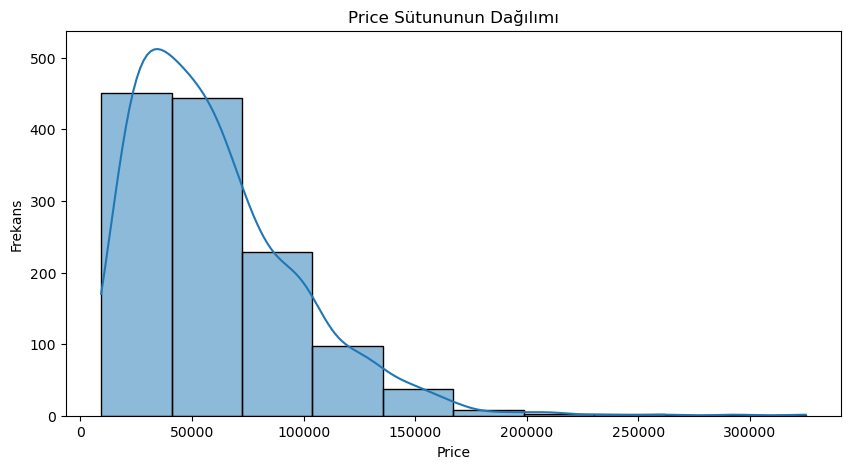

In [75]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=10,
    kde=True
)

plt.title("Price Sütununun Dağılımı")
plt.xlabel("Price")
plt.ylabel("Frekans")
plt.show()

In [76]:
# A prominent right-skewed distribution is observed. 
# Consequently, if outlier treatment is required, the non-parametric IQR method should be applied.

**Evaluation:** 

Our exploratory analysis and outlier diagnostics indicate that several observations qualify as statistical outliers. However, there is no evidence suggesting these values are erroneous or unrealistic within the domain context. To prevent unnecessary data loss, we have decided to retain all observations without applying dropping or truncation procedures.

<div class="alert alert-block alert-info alert">

## <span style=" color:red"> Analysis Goal

<div class="alert alert-block alert-success">

### <span style=" color:red"> Distribution of Price:

- Create a histogram or box plot to visualize the price distribution.

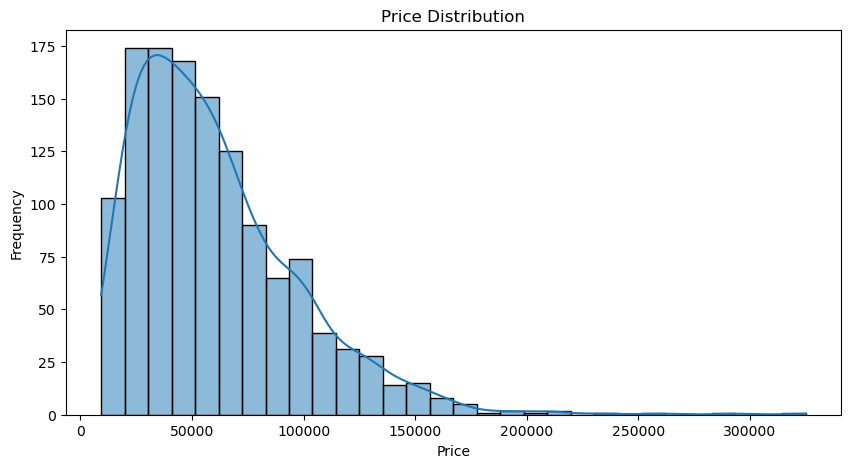

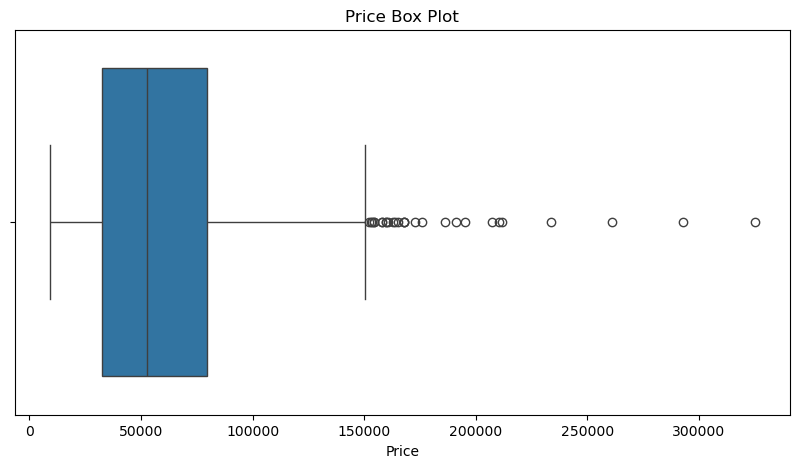

In [77]:
# The histogram illustrates the price distribution and density concentrations.
# The plot shows a right-skewed distribution, where density declines progressively as prices increase.

plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# The box plot highlights the visual presence of statistical outliers.
# Values exceeding approximately 150k are identified as outliers, mirroring the results obtained from our earlier IQR calculations.

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Price"])
plt.title("Price Box Plot")
plt.xlabel("Price")
plt.show()

### <span style=" color:red"> Company-wise Analysis:

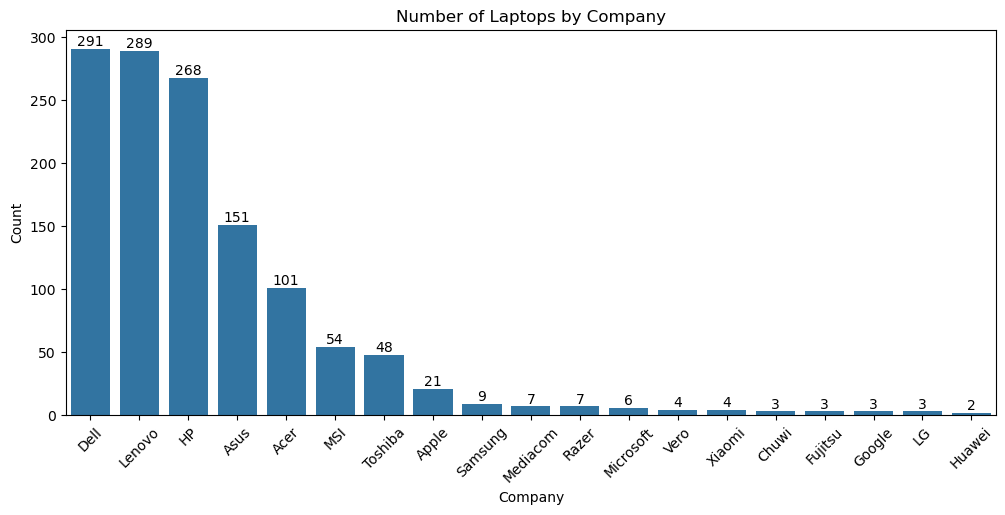

In [78]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x="Company",
    order=df["Company"].value_counts().index
)

ax.bar_label(ax.containers[0])

plt.xticks(rotation=45)
plt.title("Number of Laptops by Company")
plt.xlabel("Company")
plt.ylabel("Count")
plt.show()

In [79]:
# Dell leads the dataset with 291 units, followed closely by Lenovo in second place with 289 units.

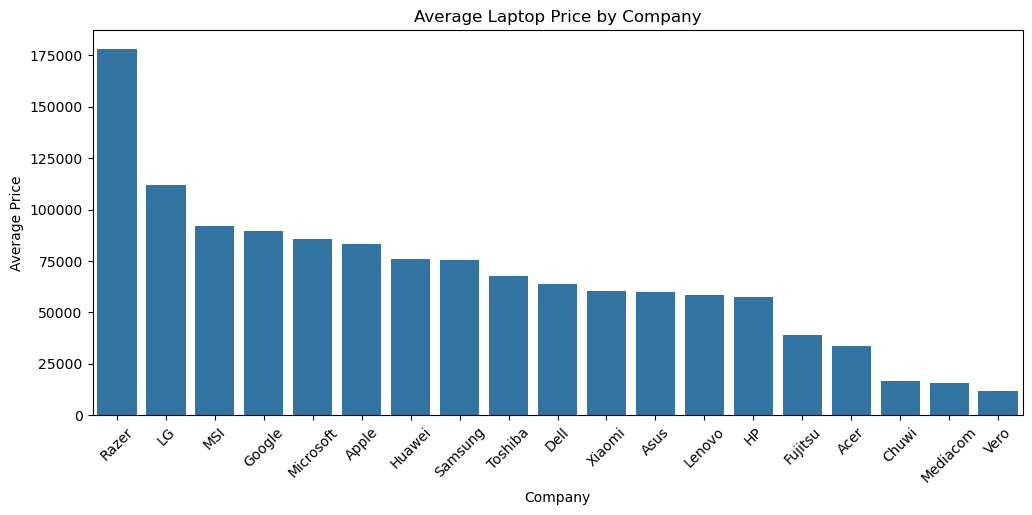

In [80]:
company_price = df.groupby("Company")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=company_price.index, y=company_price.values)
plt.xticks(rotation=45)
plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price")
plt.show()

Razer ranks first in average price, maintaining a distinct lead over LG in second place.
Despite having very low sample counts in the dataset, Razer and LG emerge as the brands with the highest mean prices.
This pattern is driven by the concentration of their limited product offerings within premium price tiers. 
Grounded in domain knowledge, a primary explanation is that these manufacturers focus heavily on high-end niche segments, specifically premium gaming laptops and ultrabooks.

### <span style=" color:red"> Relationship between Screen Size and Price:

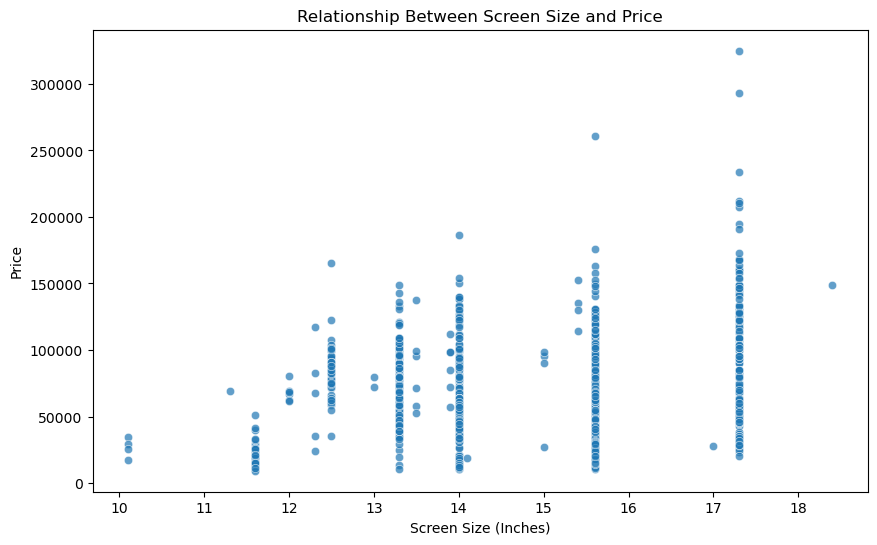

In [82]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Inches",
    y="Price",
    alpha=0.7
)

plt.xticks(range(10, 19, 1))  # 10, 11, 12, ..., 18

plt.title("Relationship Between Screen Size and Price")
plt.xlabel("Screen Size (Inches)")
plt.ylabel("Price")
plt.show()

**Absence of Direct Correlation:**

No strong linear relationship is observed between display size (Inches) and Price. Significant price variance exists within identical display sizes; for instance, 14-inch laptops span from the 50k price range up to 150k. Conversely, similar price points contain diverse screen dimensions, such as 14-inch and 15-to-16-inch configurations both coexisting at the 150k threshold. An increase in screen size does not independently drive higher prices.

**Vertical Clustering:** Data points form distinct vertical bands around standardized screen sizes—most notably at 13.3, 14, 15.6, and 17.3 inches.

**Price Variance Within Identical Screen Sizes:** Laptops with the same display size exhibit a broad price spectrum (e.g., 14-inch models spanning from 30k to 150k). Likewise, uniform price tiers encompass multiple form factors. This pattern indicates that price dispersion is governed primarily by internal hardware specifications (CPU, GPU, RAM, etc.) rather than display dimensions alone.

### <span style=" color:red"> RAM vs Price Analysis:

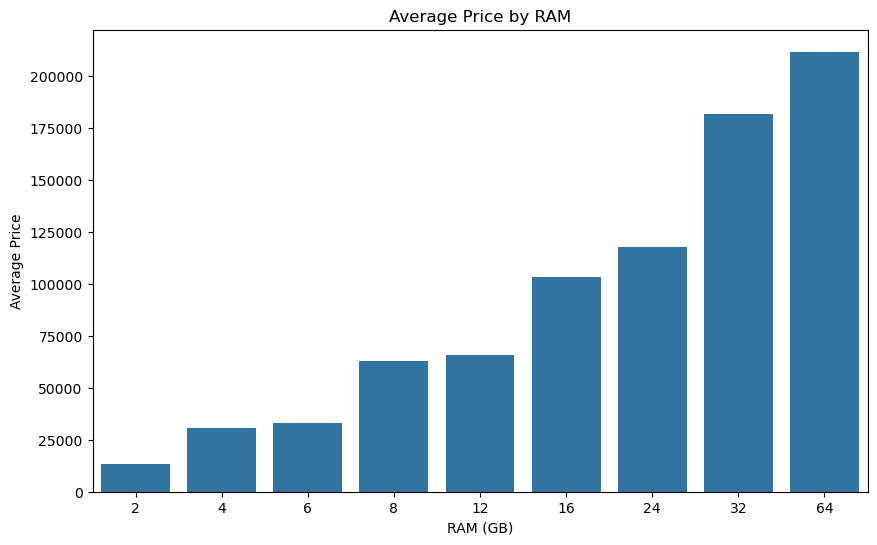

In [84]:
ram_price = df.groupby("Ram")["Price"].mean().reset_index() # Average Value!

plt.figure(figsize=(10,6))

sns.barplot(
    data=ram_price,
    x="Ram",
    y="Price"
)

plt.title("Average Price by RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price")
plt.show()

**RAM vs. Price Relationship Evaluation:**

**Strong Positive Correlation:** A distinct and strong positive correlation exists between RAM capacity and average price. As RAM capacity increases, the average price of laptops exhibits a consistent upward trend.

**Boundary Values:** The lowest average price is observed in devices with 2 GB RAM, whereas the highest average price occurs in configurations with 64 GB RAM.

**Validation of the Hardware Hypothesis:** The decisive price relationship that was absent in display size is clearly evident in the RAM feature. This confirms that RAM capacity serves as one of the primary price drivers in laptop market valuation.

### <span style=" color:red"> Operating System Market Share:

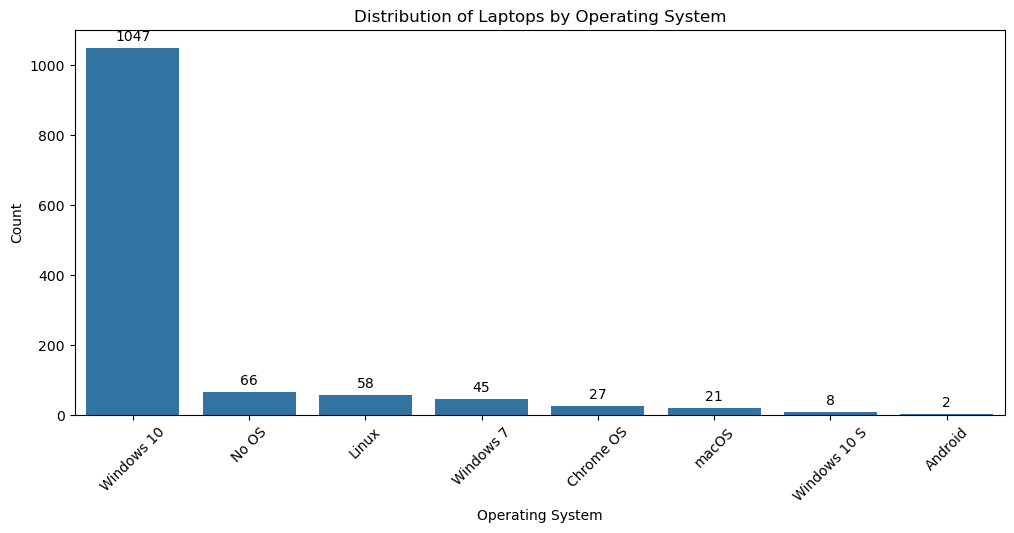

In [86]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x="OpSys",
    order=df["OpSys"].value_counts().index
)

ax.bar_label(ax.containers[0], padding=3)

plt.xticks(rotation=45)
plt.title("Distribution of Laptops by Operating System")
plt.xlabel("Operating System")
plt.ylabel("Count")
plt.show()

**Overwhelming Dominance:** The vast majority of laptops in the dataset (1,045 units, representing approximately 80%) feature the Windows 10 operating system. Other operating systems account for significantly lower market shares.

### <span style=" color:red"> Weight Distribution:

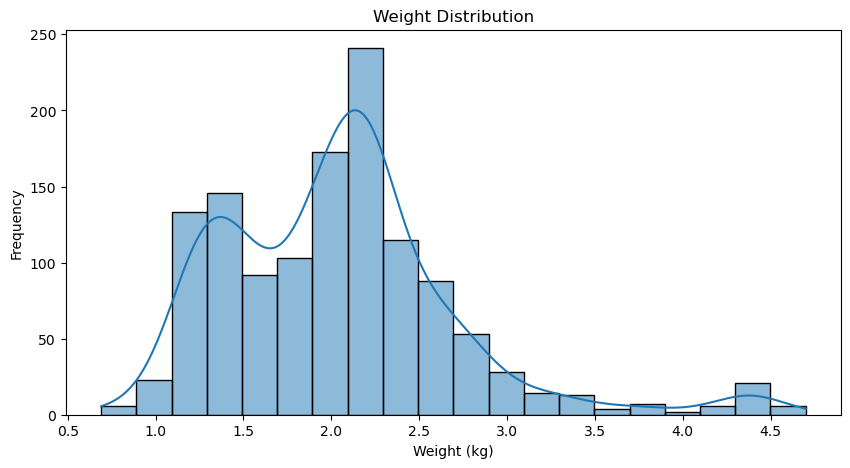

In [88]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Weight",
    bins=20,
    kde=True
)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")
plt.show()

**Weight Distribution Evaluation:**

**Right-Skewed Distribution:** The Weight feature exhibits a right-skewed distribution. The majority of laptops are heavily concentrated within the 1.5 - 2.5 kg range.

**Fluctuating Decline Trend:** Following the peak frequency, the count decreases with noticeable fluctuations. As weight increases—particularly beyond 3 kg—the observation count drops significantly.

### <span style=" color:red"> Price Correlation Analysis:

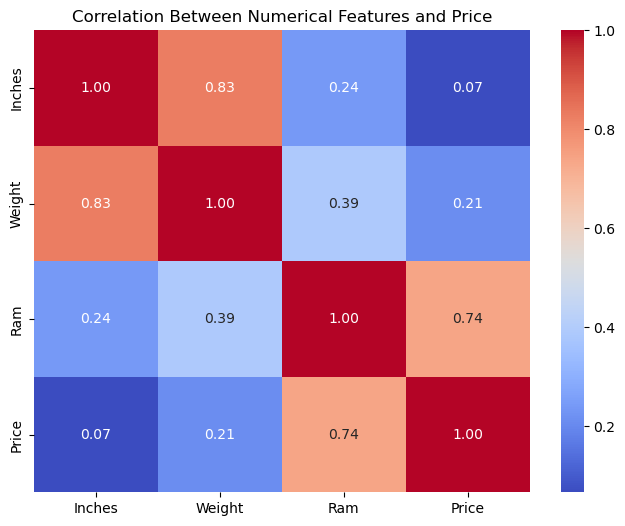

In [90]:
corr = df[["Inches", "Weight", "Ram", "Price"]].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Features and Price")
plt.show()

**Numerical Variables Correlation Evaluation:**

**Strongest Relationship (Physical Dimensions):** The highest correlation is observed between Inches (Display Size) and Weight at 0.83. Physically, an increase in chassis dimensions directly corresponds to an increase in weight.

**Primary Price Driver:** The numerical variable exhibiting the **highest correlation with Price is RAM.** This confirms that RAM capacity serves as the strongest numerical indicator governing device tiering and price positioning.

**Non-Linear / Weak Feature:** The feature with the lowest correlation to Price is Inches at 0.07. This statistical metric confirms our previous scatter plot finding that screen size alone holds no deterministic impact on price.

### <span style=" color:red"> ScreenResolution Impact on Price:

In [92]:
# Previously, we created a new column named "screen_type" to separate and categorize screen resolutions.

In [93]:
df["Screen_Type"].unique()

array(['RETINA DISPLAY', 'OTHER', 'FULL HD', 'QUAD HD+', '4K ULTRA HD'],
      dtype=object)

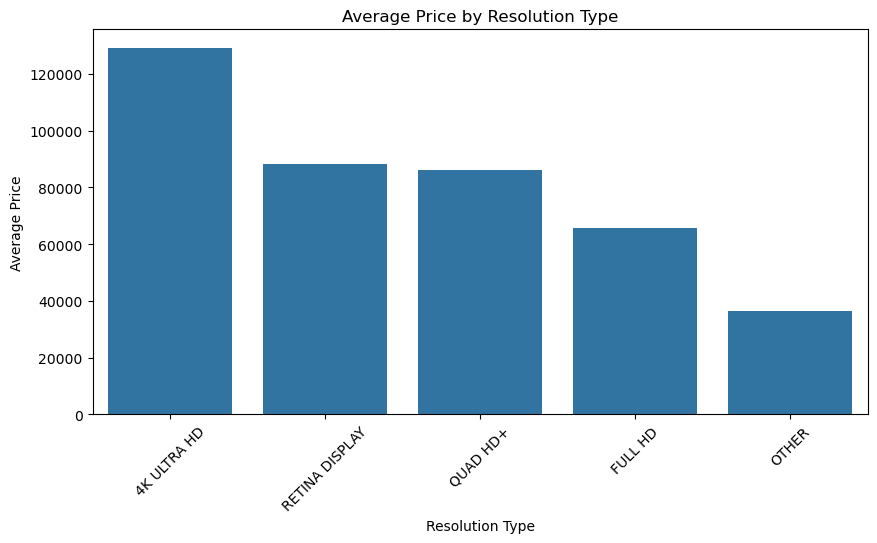

In [94]:
resolution_price = (
    df.groupby("Screen_Type")["Price"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resolution_price,
    x="Screen_Type",
    y="Price"
)

plt.xticks(rotation=45)
plt.title("Average Price by Resolution Type")
plt.xlabel("Resolution Type")
plt.ylabel("Average Price")
plt.show()

**Screen Resolution and Price Relationship Evaluation:**

**Highest Average Price:** As expected, the highest average price is observed in the 4K Ultra HD screen type. High-resolution panels carry high intrinsic manufacturing costs and necessitate pairing with more powerful processors and graphics cards to drive the additional display load, ultimately pushing average prices into the top tier.

**Premium Segment Balance:** Retina Display and Quad HD+ resolutions exhibit remarkably similar average price levels, forming the second-highest pricing tier right behind 4K.

**Resolution Impact** Average prices scale up noticeably as panel resolution increases (pixel density scales). While 4K Ultra HD occupies the highest price band, standard resolutions (Full HD or HD) form the baseline tier. This confirms screen technology as a crucial hardware component governing pricing strategy.

### <span style=" color:red"> Top CPU/GPU Manufacturers:

In [126]:
# Previously, we extracted CPU and GPU manufacturer names to create distinct "Cpu_Manufacturer" and "Gpu_Manufacturer" columns.

df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,Touchscreen,IPS,Screen_Type,Cpu_Manufacturer,Gpu_Manufacturer,Memory_Type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560x1600,False,True,RETINA DISPLAY,Intel,Intel,SSD
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440x900,False,False,OTHER,Intel,Intel,Flash Storage


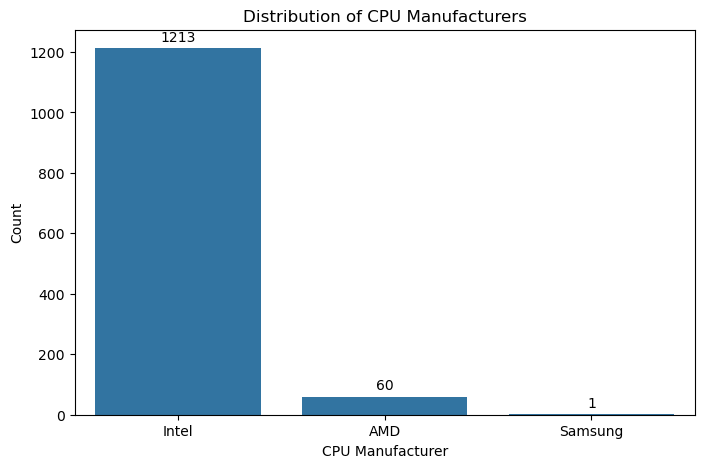

In [97]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Cpu_Manufacturer",
    order=df["Cpu_Manufacturer"].value_counts().index
)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Distribution of CPU Manufacturers")
plt.xlabel("CPU Manufacturer")
plt.ylabel("Count")
plt.show()

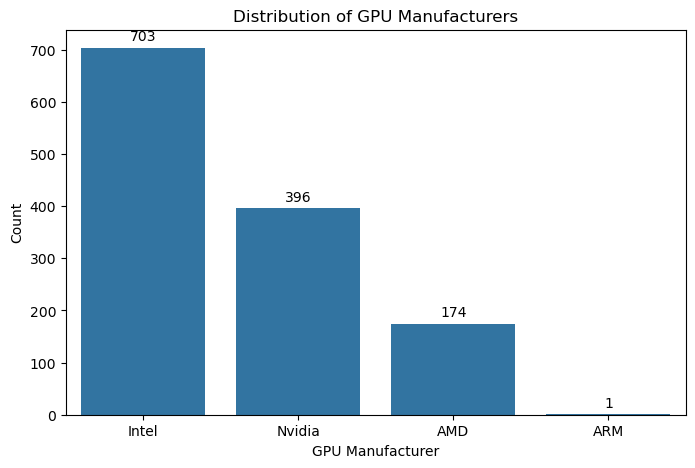

In [98]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Gpu_Manufacturer",
    order=df["Gpu_Manufacturer"].value_counts().index
)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Distribution of GPU Manufacturers")
plt.xlabel("GPU Manufacturer")
plt.ylabel("Count")
plt.show()

**CPU and GPU Manufacturer Distribution Evaluation:**

**Overwhelming Dominance in CPU Market:** Intel almost single-handedly controls the market with 1,213 units. AMD holds a limited market share with only 60 units.

**Integrated Graphics Impact in GPU Market:** On the graphics side, Intel takes first place with 703 units. This trend is driven by integrated GPU solutions built directly into the central processors.

**Dedicated Graphics Cards:** Nvidia (369 units) and AMD (174 units) represent discrete GPU market presence, highlighting the performance-oriented laptop segment.

### <span style=" color:red"> RAM Analysis:

In [100]:
ram_summary = (
    df.groupby("Ram")
      .agg(
          Laptop_Count=("Ram", "count"),
          Average_Price=("Price", "mean")
      )
      .sort_values("Laptop_Count", ascending=False)
)

ram_summary

,Laptop_Count,Average_Price
Ram,,
8,613,63106.399110
4,366,30725.242544
16,198,103426.767345
6,35,32999.318126
12,25,66037.277952
32,17,181849.215812
2,16,13193.959500
24,3,117553.440000
64,1,211788.000000


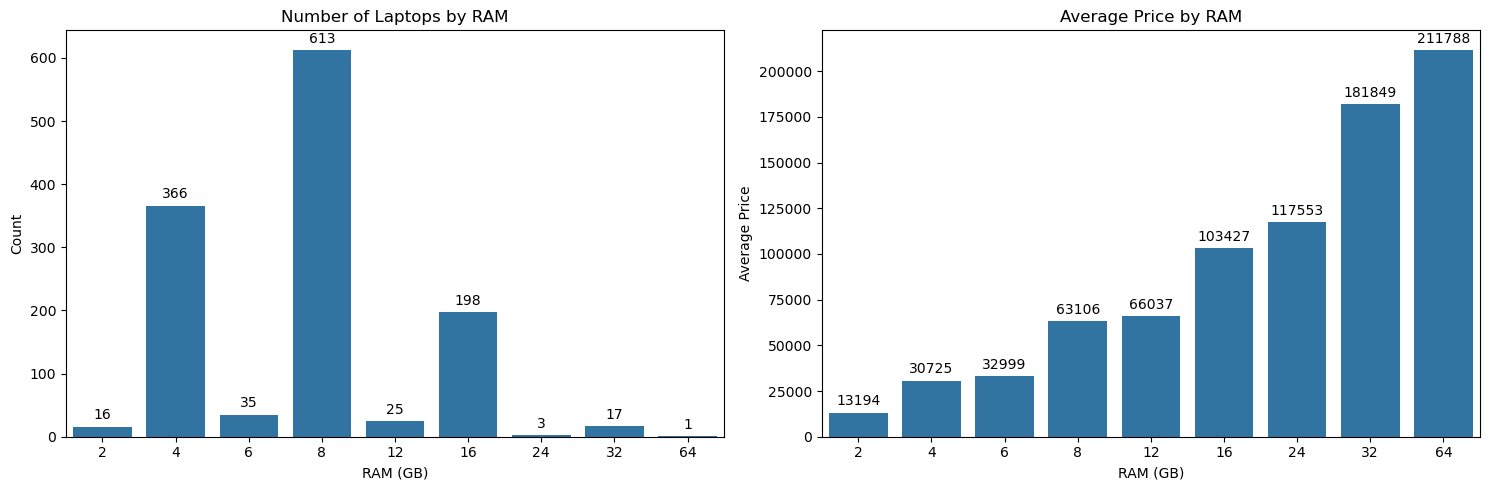

In [101]:
ram_summary = (
    df.groupby("Ram")
      .agg(
          Laptop_Count=("Ram", "count"),
          Average_Price=("Price", "mean")
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Laptop sayısı
ax1 = sns.barplot(
    data=ram_summary,
    x="Ram",
    y="Laptop_Count",
    ax=axes[0]
)
ax1.bar_label(ax1.containers[0], padding=3)
axes[0].set_title("Number of Laptops by RAM")
axes[0].set_xlabel("RAM (GB)")
axes[0].set_ylabel("Count")

# Ortalama fiyat
ax2 = sns.barplot(
    data=ram_summary,
    x="Ram",
    y="Average_Price",
    ax=axes[1]
)
ax2.bar_label(ax2.containers[0], fmt="%.0f", padding=3)
axes[1].set_title("Average Price by RAM")
axes[1].set_xlabel("RAM (GB)")
axes[1].set_ylabel("Average Price")

plt.tight_layout()
plt.show()

**RAM Configuration and Price Analysis Evaluation:**

**Most Common Configurations:** The most prevalent RAM capacity in the market is 8 GB with 613 units, followed by 4 GB with 366 units. Together, these two configurations account for the vast majority of laptops in the dataset.

**Capacity and Price Hierarchy:** While the lowest average price is observed in entry-level devices with 2 GB RAM, average prices exhibit a consistent upward progression alongside increasing RAM capacity.

**Niche/Premium Segment Devices:** High-capacity configurations such as 32 GB and 64 GB are low-volume niche models (with 64 GB limited to a single observation), yet they command the highest average price tier.

### <span style=" color:red"> Memory Type and Price Relationship:

In [103]:
# First, we need to separate storage technologies into categories such as SSD, HDD, etc., and engineer a new column.

In [104]:
df["Memory"].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [105]:
# Bir fonksiyon oluşturarak memory type'larının ayrılmasını ve yeni oluşturulan bir sutuna atanmasını sağlayacağız.

def memory_type(memory):
    if "SSD" in memory and "HDD" in memory:
        return "SSD + HDD"
    elif "SSD" in memory and "Hybrid" in memory:
        return "SSD + Hybrid"
    elif "Flash Storage" in memory and "HDD" in memory:
        return "Flash Storage + HDD"
    elif "SSD" in memory:
        return "SSD"
    elif "HDD" in memory:
        return "HDD"
    elif "Flash Storage" in memory:
        return "Flash Storage"
    elif "Hybrid" in memory:
        return "Hybrid"

df["Memory_Type"] = df["Memory"].apply(memory_type)

In [106]:
# check

df[["Memory", "Memory_Type"]].head(10)

,Memory,Memory_Type
0,128GB SSD,SSD
1,128GB Flash Storage,Flash Storage
2,256GB SSD,SSD
3,512GB SSD,SSD
4,256GB SSD,SSD
5,500GB HDD,HDD
6,256GB Flash Storage,Flash Storage
7,256GB Flash Storage,Flash Storage
8,512GB SSD,SSD
9,256GB SSD,SSD


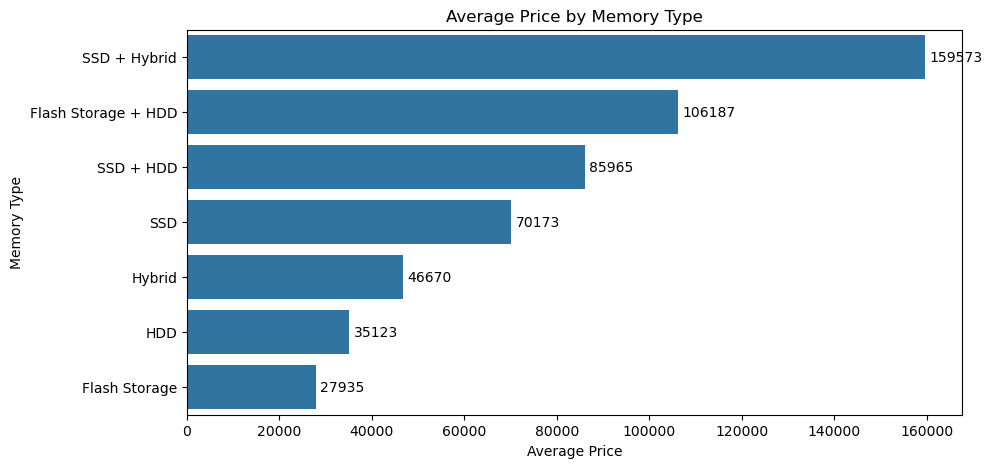

In [107]:
memory_price = (
    df.groupby("Memory_Type")["Price"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=memory_price,
    x="Price",
    y="Memory_Type"
)

ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

plt.title("Average Price by Memory Type")
plt.xlabel("Average Price")
plt.ylabel("Memory Type")

plt.show()

**Storage Type and Price Relationship Evaluation:**

**Highest Priced Combination:** The highest average price is observed in devices featuring the SSD + Hybrid storage combination.

**Dual-Storage Impact:** Dual-storage configurations, such as SSD + Hybrid and SSD + HDD, deliver a synergy of high performance and expansive storage capacity. Consequently, they are predominantly deployed in premium and performance-oriented segments, driving higher average market prices.

**Technological Divergence (SSD vs HDD / Flash):** Among standalone storage units, modern high-speed SSD technology maintains a distinct price premium. In contrast, traditional HDDs and budget-oriented Flash Storage solutions populate the lower price tiers.

### <span style=" color:red"> TypeName Analysis:

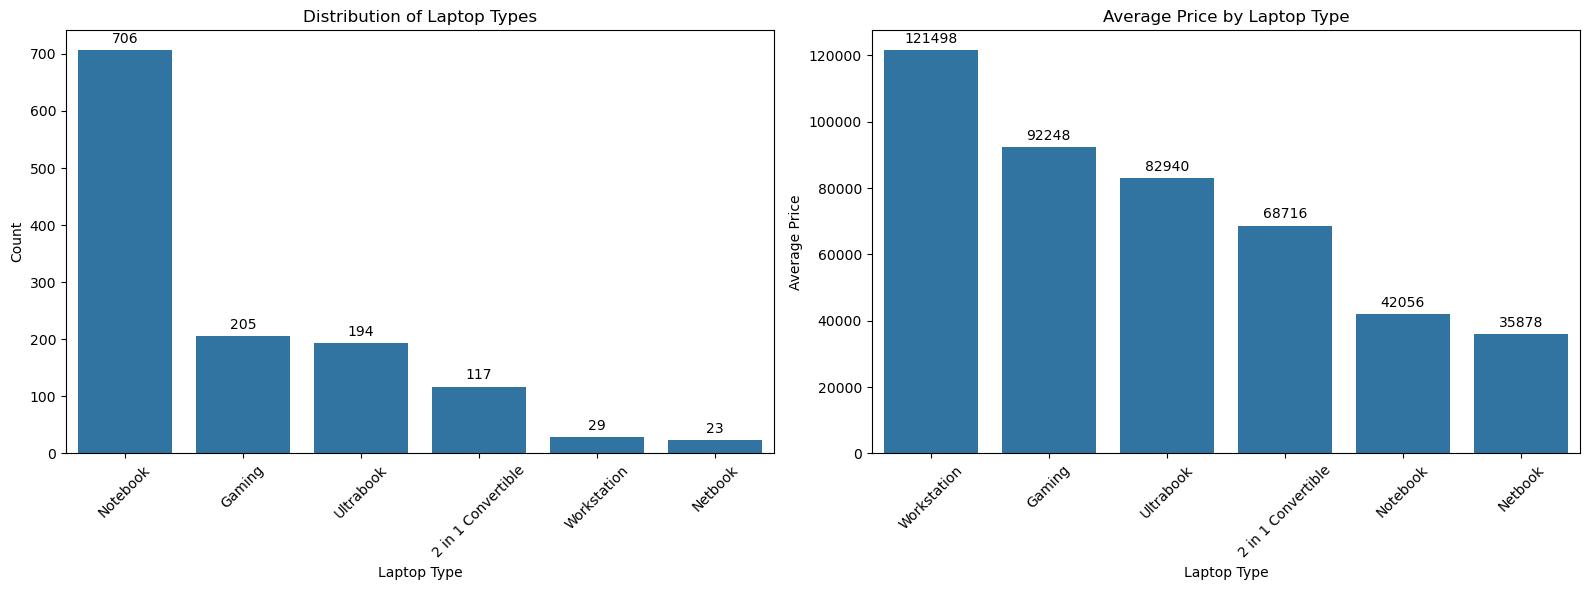

In [113]:
type_price = (
    df.groupby("TypeName")["Price"]
      .mean()
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Laptop Typename

ax1 = sns.countplot(
    data=df,
    x="TypeName",
    order=df["TypeName"].value_counts().index,
    ax=axes[0]
)

ax1.bar_label(ax1.containers[0], padding=3)

axes[0].set_title("Distribution of Laptop Types")
axes[0].set_xlabel("Laptop Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# 2. Laptop typename & price 

ax2 = sns.barplot(
    data=type_price,
    x="TypeName",
    y="Price",
    order=type_price.sort_values("Price", ascending=False)["TypeName"],
    ax=axes[1]
)

ax2.bar_label(ax2.containers[0], fmt="%.0f", padding=3)

axes[1].set_title("Average Price by Laptop Type")
axes[1].set_xlabel("Laptop Type")
axes[1].set_ylabel("Average Price")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Device Type (TypeName) and Price Relationship Evaluation:**

**Volume Dominance:** The most common device type in the dataset is the Notebook. Targeted at standard usage, this category constitutes the primary core of the market.

**Peak Performance Segment:** Workstation commands the highest average price among device types, closely followed by the Gaming category in second place. This indicates that hardware built for heavy workloads and intensive graphical performance drives prices into the highest tier.

**Portability Premium:** Thin, lightweight, and mobility-focused categories such as Ultrabook and 2 in 1 Convertible maintain a higher average price point compared to the standard Notebook segment.

### <span style=" color:red"> Touchscreen and Price Relationship

In [115]:
df.groupby("Touchscreen")["Price"].mean()

# Average price comparison: Touchscreen vs. Non-Touchscreen laptops

Touchscreen
False    57574.306674
True     77422.131574
Name: Price, dtype: float64

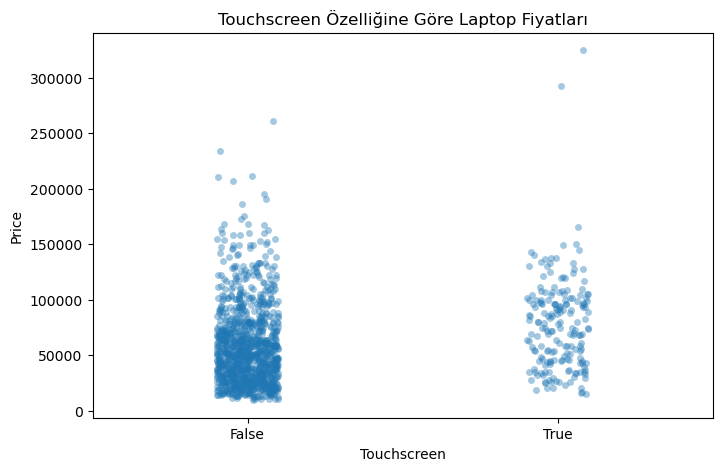

In [116]:
# Price distribution across both groups

plt.figure(figsize=(8,5))

sns.stripplot(
    data=df,
    x="Touchscreen",
    y="Price",
    alpha=0.4
)

plt.title("Touchscreen Özelliğine Göre Laptop Fiyatları")
plt.xlabel("Touchscreen")
plt.ylabel("Price")
plt.show()

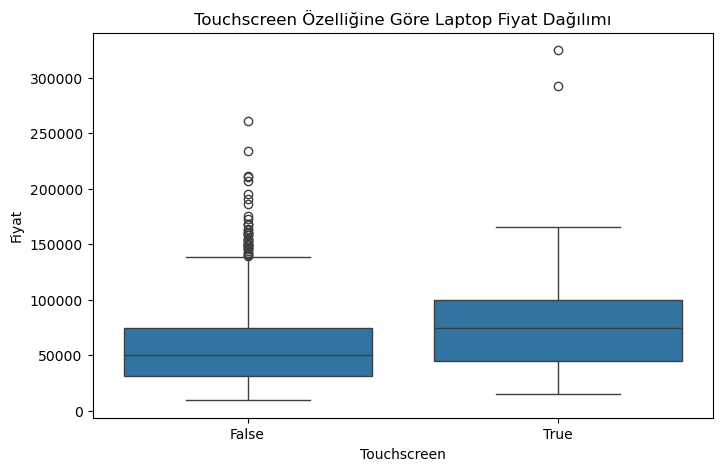

In [117]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Touchscreen",
    y="Price"
)

plt.title("Touchscreen Özelliğine Göre Laptop Fiyat Dağılımı")
plt.xlabel("Touchscreen")
plt.ylabel("Fiyat")
plt.show()

In [118]:
Q1 = df.groupby("Touchscreen")["Price"].quantile(0.25)
Q3 = df.groupby("Touchscreen")["Price"].quantile(0.75)

IQR = Q3 - Q1

outlier_count = (
    df.groupby("Touchscreen")["Price"]
      .apply(lambda x: ((x < Q1[x.name] - 1.5 * IQR[x.name]) |
                        (x > Q3[x.name] + 1.5 * IQR[x.name])).sum())
)

print(outlier_count)

Touchscreen
False    39
True      2
Name: Price, dtype: int64


**Price Impact of Touchscreen Capability**

**Average Price Margin:** The average price of laptops equipped with a Touchscreen (77,422 units) is significantly higher compared to non-Touchscreen devices (57,574 units). Touchscreen technology acts as a premium hardware feature that pushes up baseline pricing.

**Outlier Distribution:** The non-Touchscreen cohort exhibits 39 identified outliers. This highlights a broad spectrum of high-end devices—such as specialized Gaming rigs or Workstations—that command extreme prices based on GPU, CPU, or build quality rather than touch integration.

Conversely, the Touchscreen cohort features only 2 outliers. Touchscreen devices generally cluster at an elevated price baseline with a much tighter distribution band.

### <span style=" color:red"> High-end Laptop Analysis:

In [ ]:
# Selecting and analyzing the highest-priced laptop in the dataset.

In [121]:
df.sort_values(by = "Price", ascending = False)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,Touchscreen,IPS,Screen_Type,Cpu_Manufacturer,Gpu_Manufacturer,Memory_Type
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,324954.720,3840x2160,True,False,4K ULTRA HD,Intel,Nvidia,SSD
830,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,512GB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,292986.720,3840x2160,True,False,4K ULTRA HD,Intel,Nvidia,SSD
610,Lenovo,Notebook,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Xeon E3-1535M v6 3.1GHz,32,1TB SSD,Nvidia Quadro M2200M,Windows 10,2.50,261018.720,3840x2160,False,True,4K ULTRA HD,Intel,Nvidia,SSD
749,HP,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel Xeon E3-1535M v5 2.9GHz,16,256GB SSD,Nvidia Quadro M2000M,Windows 7,3.00,233845.920,1920x1080,False,True,FULL HD,Intel,Nvidia,SSD
1066,Asus,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,64,1TB SSD,Nvidia GeForce GTX 980,Windows 10,3.58,211788.000,1920x1080,False,True,FULL HD,Intel,Nvidia,SSD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,Asus,Notebook,14.0,1366x768,AMD E-Series E2-6110 1.5GHz,2,32GB Flash Storage,AMD Radeon R2,Windows 10,1.65,10602.720,1366x768,False,False,OTHER,AMD,AMD,Flash Storage
290,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core 3205U 1.5GHz,2,16GB SSD,Intel HD Graphics,Chrome OS,2.19,10602.720,1366x768,False,False,OTHER,Intel,Intel,SSD
1120,Vero,Notebook,13.3,Full HD 1920x1080,Intel Atom X5-Z8350 1.44GHz,4,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.35,10442.880,1920x1080,False,False,FULL HD,Intel,Intel,Flash Storage
20,Asus,Netbook,11.6,1366x768,Intel Atom x5-Z8350 1.44GHz,2,32GB Flash Storage,Intel HD Graphics 400,Windows 10,0.98,10224.432,1366x768,False,False,OTHER,Intel,Intel,Flash Storage


In [122]:
df[df["Price"] == df["Price"].max()]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Resolution,Touchscreen,IPS,Screen_Type,Cpu_Manufacturer,Gpu_Manufacturer,Memory_Type
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1TB SSD,Nvidia GeForce GTX 1080,Windows 10,3.49,324954.72,3840x2160,True,False,4K ULTRA HD,Intel,Nvidia,SSD


**High-End Laptop Analysis (Highest-Priced Outlier):**

When inspecting the highest-priced device in the dataset (priced at 324,954.72 units), it becomes evident that all top-tier premium components identified individually across our prior TypeName, Touchscreen, resolution, and hardware analyses converge within this single model:

**Brand and Segment Selection:** It belongs to Razer, one of the premium brands commanding the highest average prices. The device category is Gaming, which ranks as the second-highest average price group right behind Workstation.

**Display Technology and Features:** It features a 4K Ultra HD panel, the resolution tier associated with the highest average price. Additionally, it incorporates Touchscreen capability, which our previous analysis proved to push baseline pricing significantly higher.

**Performance and Hardware Package:**

Equipped with 32 GB RAM (the second-highest average price tier for memory).  
Utilizes a 1 TB SSD storage configuration.  
Powered by an Intel Core i7 CPU and an Nvidia GPU (GTX 1080), the leading performance driver in the discrete graphics market.

**Software and Physical Profile:** Runs on Windows 10, the market standard OS. Due to its performance-oriented cooling architecture and large 17.3-inch display, it weighs 3.49 kg—aligning directly with the right-skewed heavy tail identified in our physical weight distribution analysis.

**Summary Conclusion:** The specifications of this maximum-priced device clearly confirm that extreme market pricing stems not from an isolated hardware feature, but from a holistic, synergistic combination: Gaming Segment + Touchscreen + 4K Panel + 32GB RAM + Top-Tier Discrete GPU/CPU.

# <span style=" color:red">Conclusions

**Executive Summary / Conclusion:**

In this Exploratory Data Analysis (EDA) study, laptop market pricing dynamics, hardware component cost impacts, and market segmentation structures were rigorously evaluated using data-driven methodologies. 
Key insights derived from the analysis include:

**RAM as a Key Numerical Proxy ($r = 0.74$):** Among continuous features, the strong positive correlation ($r = 0.74$) between RAM and Price identifies memory capacity as the single most influential numerical driver of price. Rather than operating strictly as an isolated cost factor, RAM serves as the strongest proxy indicator for overall system capability—routinely co-occurring with high-end processors, discrete GPUs, and premium displays.

**Holistic Hardware Package Effect:** Market valuation depends on combined "hardware suites" rather than isolated components. Workstation and Gaming form factors command the highest average pricing tier by pairing high RAM capacities with discrete GPUs (Nvidia) and heavy-duty CPUs.

**Display and Visual Technologies:** 4K Ultra HD panel resolution and Touchscreen capabilities drive noticeable price premiums—both due to intrinsic panel manufacturing costs and the requirement for top-tier supporting hardware to drive these displays.

**Market Structure and Dominance:** Intel completely dominates the CPU market with nearly ~93% market share. In the GPU landscape, Intel maintains volume leadership due to integrated graphics prevalence, whereas Nvidia functions as the primary provider for the performance segment. For storage, SSD technology has solidified its position as the baseline industry standard.

**Validation of the High-End Outlier:** A deep-dive case study into the dataset's highest-priced laptop (Razer) confirms our broader empirical findings: extreme pricing is driven by the synergistic convergence of Gaming Segment + Touchscreen + 4K Display + 32GB RAM + Top-Tier GPU/CPU architecture. While RAM capacity ($r = 0.74$) acts as the strongest numerical indicator of system tier, target device category (TypeName), display technology, and GPU/CPU synergy represent the ultimate core value drivers governing price distribution.
